# Data Analytics and Visualization — Lab Assignment 5
## Visualization with Matplotlib and Statistical Visualization with Seaborn

## Enroll no: 2503A52163
## Name: D.Harish

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('earthquake_1995-2023.csv')

print(df.shape)
df.head()

(1000, 19)


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


In [ ]:
# Install libraries if needed in Google Colab
!pip -q install pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [ ]:
# Upload the CSV in Colab, then run this cell.
# If your file has the exact assignment name, replace the filename below.
file_path = 'earthquake_1995-2023.csv'
df = pd.read_csv(file_path)

# Convert date_time to datetime. The supplied dataset uses day-month-year format.
df['date_time'] = pd.to_datetime(df['date_time'], dayfirst=True, errors='coerce')

print('Dataset shape:', df.shape)
display(df.head())
display(df.info())

Dataset shape: (1000, 19)


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   title      1000 non-null   object        
 1   magnitude  1000 non-null   float64       
 2   date_time  1000 non-null   datetime64[ns]
 3   cdi        1000 non-null   int64         
 4   mmi        1000 non-null   int64         
 5   alert      449 non-null    object        
 6   tsunami    1000 non-null   int64         
 7   sig        1000 non-null   int64         
 8   net        1000 non-null   object        
 9   nst        1000 non-null   int64         
 10  dmin       1000 non-null   float64       
 11  gap        1000 non-null   float64       
 12  magType    1000 non-null   object        
 13  depth      1000 non-null   float64       
 14  latitude   1000 non-null   float64       
 15  longitude  1000 non-null   float64       
 16  location   994 non-null    object        
 

None

## Task 1 — Basic Charts using Matplotlib

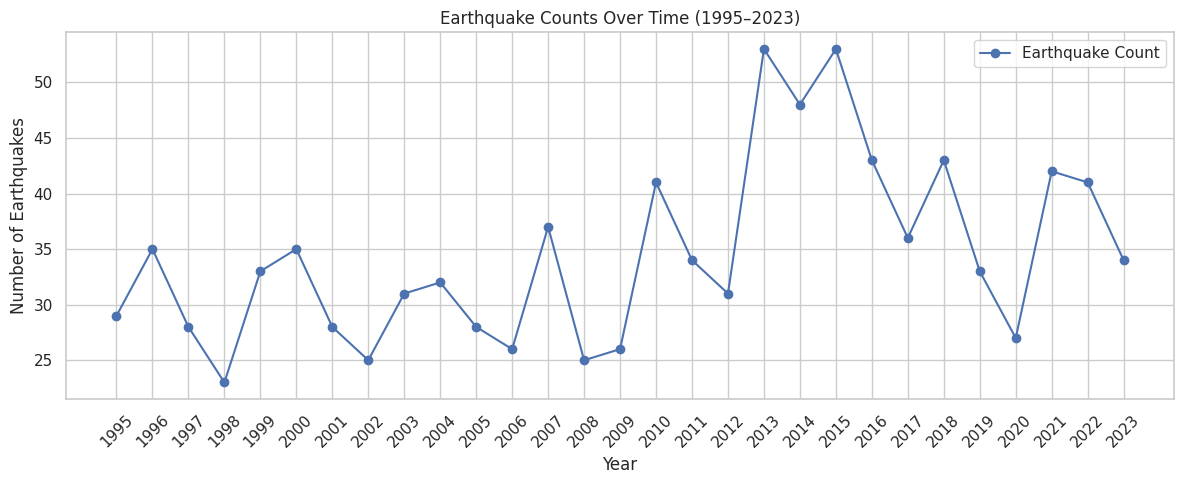

In [ ]:
# 1. Line chart — shows how the number of recorded earthquakes changes from year to year.
year_counts = df['date_time'].dt.year.value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(year_counts.index, year_counts.values, marker='o')
plt.title('Earthquake Counts Over Time (1995–2023)')
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')
plt.xticks(year_counts.index, rotation=45)
plt.legend(['Earthquake Count'])
plt.tight_layout()
plt.show()

**Conclusion:**

The line chart shows that the number of recorded earthquakes varies from year to year, with noticeable increases and decreases over the period 1995–2023.

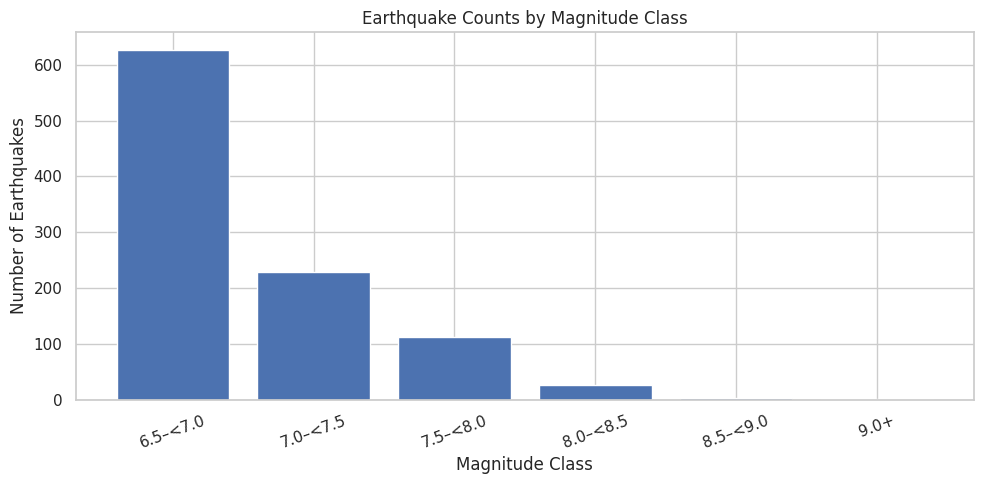

In [ ]:
# 2. Bar chart — shows the number of earthquakes in each magnitude class.
bins = [6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.2]
labels = ['6.5–<7.0', '7.0–<7.5', '7.5–<8.0', '8.0–<8.5', '8.5–<9.0', '9.0+']
df['magnitude_class'] = pd.cut(df['magnitude'], bins=bins, labels=labels, right=False, include_lowest=True)
mag_counts = df['magnitude_class'].value_counts(sort=False)

plt.figure(figsize=(10, 5))
plt.bar(mag_counts.index.astype(str), mag_counts.values)
plt.title('Earthquake Counts by Magnitude Class')
plt.xlabel('Magnitude Class')
plt.ylabel('Number of Earthquakes')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Conclusion:**

The bar chart shows that most earthquakes in the dataset fall within the 6.5–7.0 magnitude range, while the number of earthquakes decreases as magnitude increases.

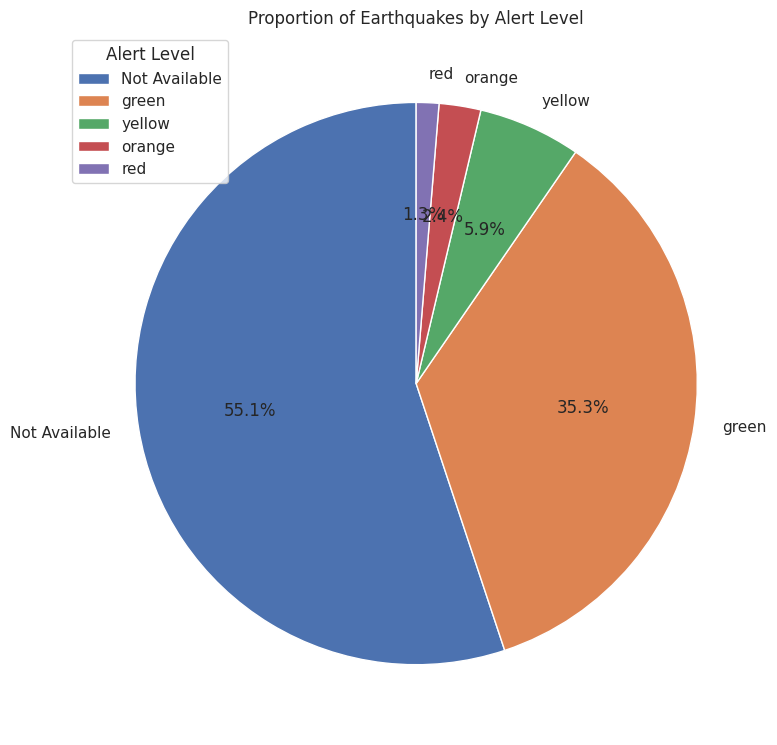

In [ ]:
# 3. Pie chart — shows the proportion of events assigned to each alert level.
# Missing alert values are grouped as 'Not Available' so every event is represented.
alert_counts = df['alert'].fillna('Not Available').value_counts()

plt.figure(figsize=(8, 8))
plt.pie(alert_counts.values, labels=alert_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Proportion of Earthquakes by Alert Level')
plt.legend(title='Alert Level', loc='best')
plt.tight_layout()
plt.show()

**Conclusion:**

The pie chart shows the proportion of earthquakes for each alert level. Green alerts form a substantial portion of the classified events, while yellow, orange, and red alerts represent smaller portions. Many records have no alert value.

## Task 2 — Statistical Visualization using Seaborn

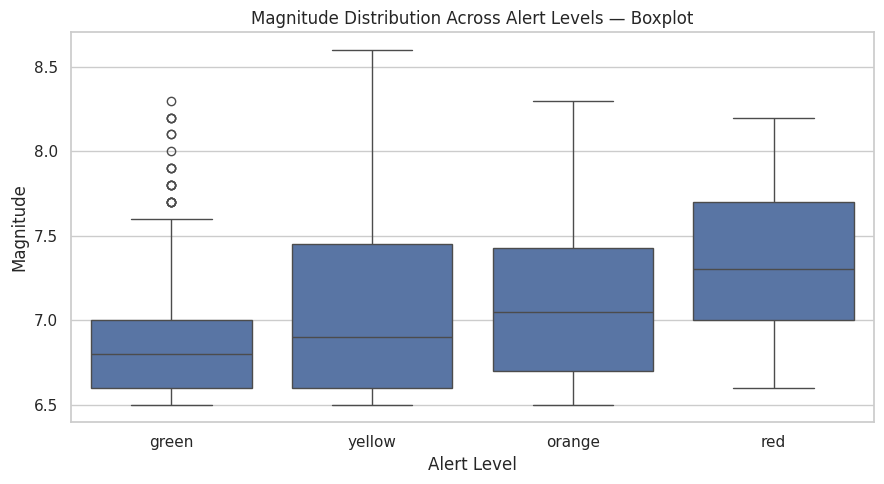

In [ ]:
# 4. Boxplot — compares median, quartiles, spread, and outliers of magnitude for each alert level.
box_df = df.dropna(subset=['alert', 'magnitude']).copy()

plt.figure(figsize=(9, 5))
sns.boxplot(data=box_df, x='alert', y='magnitude')
plt.title('Magnitude Distribution Across Alert Levels — Boxplot')
plt.xlabel('Alert Level')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()

**Conclusion:**

The boxplot compares the magnitude distributions across alert levels and shows differences in their median, spread, and outliers.

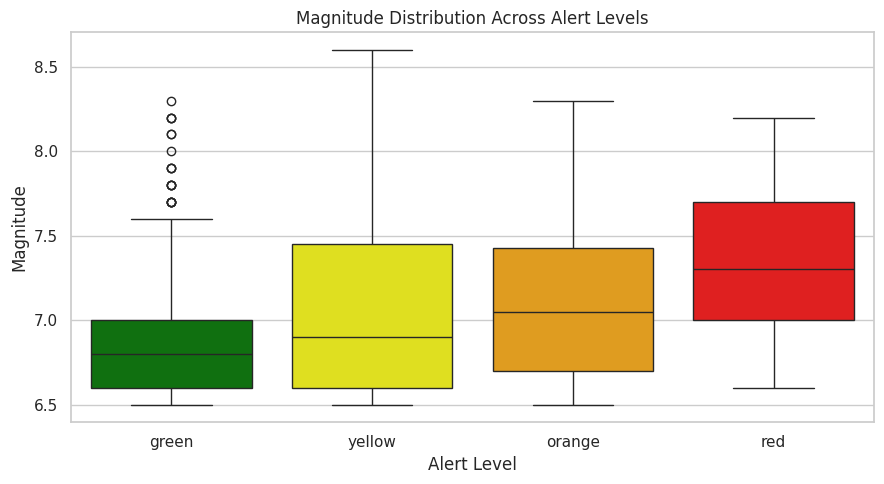

In [ ]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='alert',
    y='magnitude',
    hue='alert',
    palette={
        'green': 'green',
        'yellow': 'yellow',
        'orange': 'orange',
        'red': 'red'
    },
    legend=False
)

plt.title('Magnitude Distribution Across Alert Levels')
plt.xlabel('Alert Level')
plt.ylabel('Magnitude')

plt.tight_layout()
plt.show()

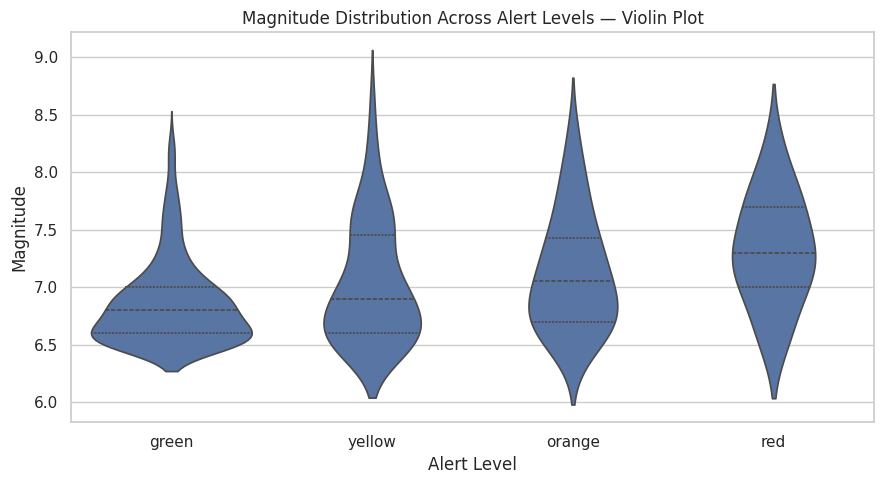

In [ ]:
# 5. Violin plot — shows the full shape and density of the magnitude distribution for each alert level.
plt.figure(figsize=(9, 5))
sns.violinplot(data=box_df, x='alert', y='magnitude', inner='quartile')
plt.title('Magnitude Distribution Across Alert Levels — Violin Plot')
plt.xlabel('Alert Level')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()

**Conclusion:**

The violin plot shows the shape and density of magnitude distributions for each alert level, making it easier to see where earthquake magnitudes are concentrated.

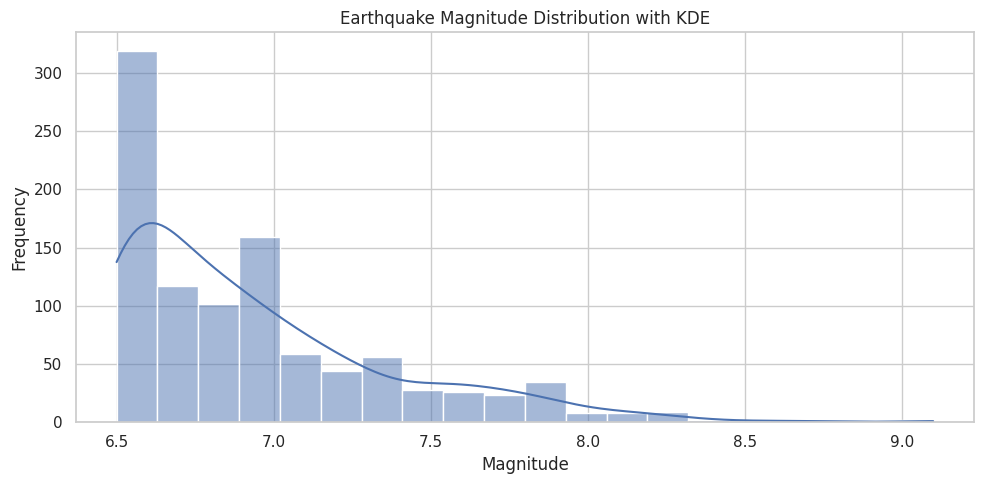

In [ ]:
# 6. Histogram + KDE — shows the frequency of magnitude values and the smoothed distribution shape.

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='magnitude',
    kde=True,
    bins=20
)

plt.title('Earthquake Magnitude Distribution with KDE')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Conclusion:**

The histogram shows that earthquake magnitudes are concentrated mainly toward the lower end of the dataset, while higher-magnitude earthquakes occur less frequently. The KDE curve shows the overall smooth distribution.

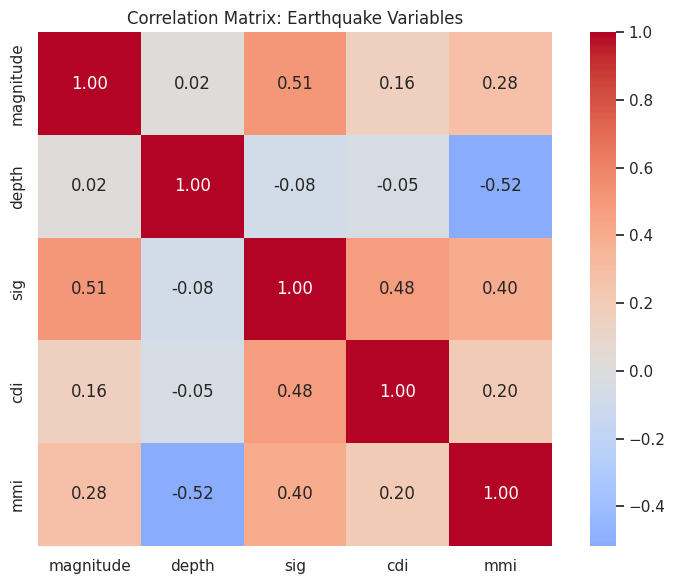

In [ ]:
# 7. Heatmap — shows the strength and direction of pairwise correlations among the selected variables.
corr_cols = ['magnitude', 'depth', 'sig', 'cdi', 'mmi']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix: Earthquake Variables')
plt.tight_layout()
plt.show()

**Conclusion:**

The heatmap represents the correlations between magnitude, depth, sig, cdi, and mmi. The color intensity and correlation values help identify stronger and weaker relationships between the variables.

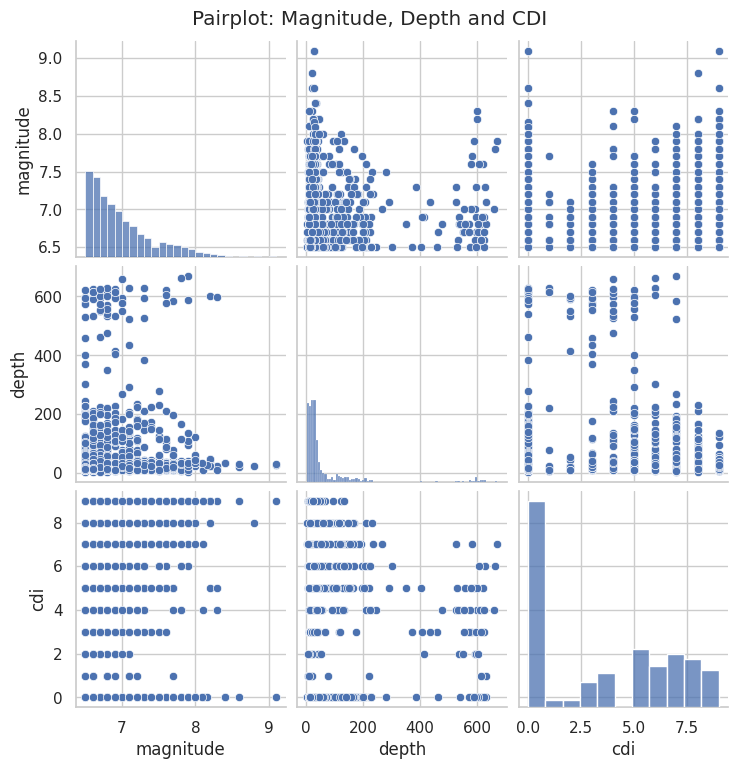

In [ ]:
# 8. Pairplot — shows multiple pairwise relationships and distributions for magnitude, depth, and felt reports (cdi).
pair_df = df[['magnitude', 'depth', 'cdi']].dropna()
g = sns.pairplot(pair_df, diag_kind='hist')
g.fig.suptitle('Pairplot: Magnitude, Depth and CDI', y=1.02)
plt.show()

**Conclusion:**

The pairplot provides a visual comparison of the relationships between magnitude, depth, and CDI, while also showing the individual distribution of each variable.

## Conclusion
The notebook contains all eight required visualizations: three Matplotlib charts and five Seaborn statistical visualizations. The charts help examine earthquake counts over time, magnitude classes, alert-level proportions, distributions, correlations, and relationships among magnitude, depth, and CDI.